In [1]:
import subprocess
import sys
from importlib_metadata import version as pkg_version, PackageNotFoundError

packages = ["torch", "torchvision", "torchmetrics", "matplotlib", "scikit-learn", "kagglehub"]

print("####################################################################")
print("Checking packages and upgrading only if needed (local check)...")
print("-----------------------------------")

for pkg in packages:
    try:
        installed_version = pkg_version(pkg)
        print(f"{pkg} is installed (version {installed_version}). Checking for upgrade...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", pkg])
    except PackageNotFoundError:
        print(f"{pkg} is not installed. Installing now...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

print("####################################################################")

####################################################################
Checking packages and upgrading only if needed (local check)...
-----------------------------------
torch is installed (version 2.10.0+cu128). Checking for upgrade...
torchvision is installed (version 0.25.0+cu128). Checking for upgrade...
torchmetrics is not installed. Installing now...
matplotlib is installed (version 3.10.0). Checking for upgrade...
scikit-learn is installed (version 1.6.1). Checking for upgrade...
kagglehub is installed (version 0.3.13). Checking for upgrade...
####################################################################


In [2]:
# Handle imports
import os
import torch
from sklearn.preprocessing import LabelEncoder
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import kagglehub
import utils
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from torchmetrics.classification import MulticlassCalibrationError
import matplotlib.pyplot as plt

In [3]:
env = input("Please tell me if you are running code on Kaggle, colab or Local? (kaggle/colab/local): ").strip().lower()

model_name = "resnet"
prev_stage = None

path_final_models, path_hackathon_checkpoints, path_plots, path_oct_models = utils.create_paths(model_name=model_name, augmented=True, env=env)

Please tell me if you are running code on Kaggle, colab or Local? (kaggle/colab/local): colab
Mounted at /content/drive
Running in Colab environment.
The path are:
Final Models: /content/drive/MyDrive/Final_Models/resnet_aug
Hackathon Checkpoints: /content/drive/MyDrive/hackathon_checkpoints/resnet_aug
Plots: /content/drive/MyDrive/plots/resnet_aug
OCT Models: /content/drive/MyDrive/oct_models/resnet_aug


In [4]:
# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("####################################################################")
print("Using device:", device)
print("####################################################################")

####################################################################
Using device: cuda
####################################################################


In [7]:
# Download dataset if needed
DATA_PATH = kagglehub.dataset_download("mislamshawon/oct2017")
print("####################################################################################")
print("The path for the dataset is:", DATA_PATH)
print("####################################################################")

# Check folder exists
if os.path.exists(DATA_PATH):
    print("Data folder contents:", os.listdir(os.path.join(DATA_PATH)))
    print("####################################################################")
    print("Train folder contents:", os.listdir(os.path.join(DATA_PATH, "train")))
    print("####################################################################")
    print("Val folder contents:", os.listdir(os.path.join(DATA_PATH, "val")))
    print("####################################################################")
    print("Test folder contents:", os.listdir(os.path.join(DATA_PATH, "test")))
    print("####################################################################")
else:
    print("Path does not exist!")

# Set random seed = 42
rand_seed = 42
np.random.seed(rand_seed)
torch.manual_seed(rand_seed)
torch.cuda.manual_seed_all(rand_seed)

Using Colab cache for faster access to the 'oct2017' dataset.
####################################################################################
The path for the dataset is: /kaggle/input/oct2017
####################################################################
Data folder contents: ['val', 'test', 'train']
####################################################################
Train folder contents: ['DRUSEN', 'CNV', 'NORMAL', 'DME']
####################################################################
Val folder contents: ['DRUSEN', 'CNV', 'NORMAL', 'DME']
####################################################################
Test folder contents: ['DRUSEN', 'CNV', 'NORMAL', 'DME']
####################################################################


In [8]:
# Create separate DataFrames
train_df  = utils.create_dataframe("train", DATA_PATH)
val_df  = utils.create_dataframe("val", DATA_PATH)
test_df  = utils.create_dataframe("test", DATA_PATH)

sum_total_data = len(train_df)+len(val_df)+len(test_df)
print("####################################################################")
print("The total images in the dataset are:", (sum_total_data), "images")
print("####################################################################")

print("####################################################################")
print("The size of the imported data in each folder is:")
print("A) Train size:", len(train_df),"images [",len(train_df)/(sum_total_data) *100,"% ]")
print("B) Validation size:", len(val_df),"images [",len(val_df)/(sum_total_data) *100,"% ]")
print("C) Test size:", len(test_df),"images [",len(test_df)/(sum_total_data) *100,"% ]")
print("####################################################################")

####################################################################
The total images in the dataset are: 84130 images
####################################################################
####################################################################
The size of the imported data in each folder is:
A) Train size: 50580 images [ 60.12124093664567 % ]
B) Validation size: 16851 images [ 20.029715915844527 % ]
C) Test size: 16699 images [ 19.849043147509807 % ]
####################################################################


In [9]:
# Encode Labels to Numbers
le = LabelEncoder()

train_df["label_encoded"] = le.fit_transform(train_df["label"])
val_df["label_encoded"] = le.transform(val_df["label"])
test_df["label_encoded"] = le.transform(test_df["label"])
print("####################################################################")
print("The names of the classes in OCT classification are:")
print("Classes:", le.classes_)
print("Classes have been labeled as 0, 1, 2, 3.")
print("####################################################################")

####################################################################
The names of the classes in OCT classification are:
Classes: ['CNV' 'DME' 'DRUSEN' 'NORMAL']
Classes have been labeled as 0, 1, 2, 3.
####################################################################


In [10]:
# Image transformation
transform_no_aug = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [11]:
# Pass Transform Into Dataset
test_dataset = utils.OCTDataset(test_df, transform=transform_no_aug)

In [12]:
# Create DataLoaders
print("####################################################################")
while True:
    BATCH_SIZE = int(input("Enter batch size (e.g., 32, 64, 128): "))
    if BATCH_SIZE % 8 != 0 and BATCH_SIZE != 1:
        print("Please enter a batch size that is a multiple of 8")
    else:
        break
print("Using batch size:", BATCH_SIZE)
print("####################################################################")

test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

####################################################################
Enter batch size (e.g., 32, 64, 128): 512
Using batch size: 512
####################################################################



                                        Testing Final Model: ResNet18 with Augmentation


Testing: 100%|██████████| 261/261 [33:23<00:00,  7.68s/batch]



--- Metrics ---
Accuracy: 0.9637 | Precision: 0.9442 | Recall: 0.9539 | F1 Score: 0.9489
Plot saved to /content/drive/MyDrive/plots/resnet_aug/ResNet18_cm_roc_aug.png


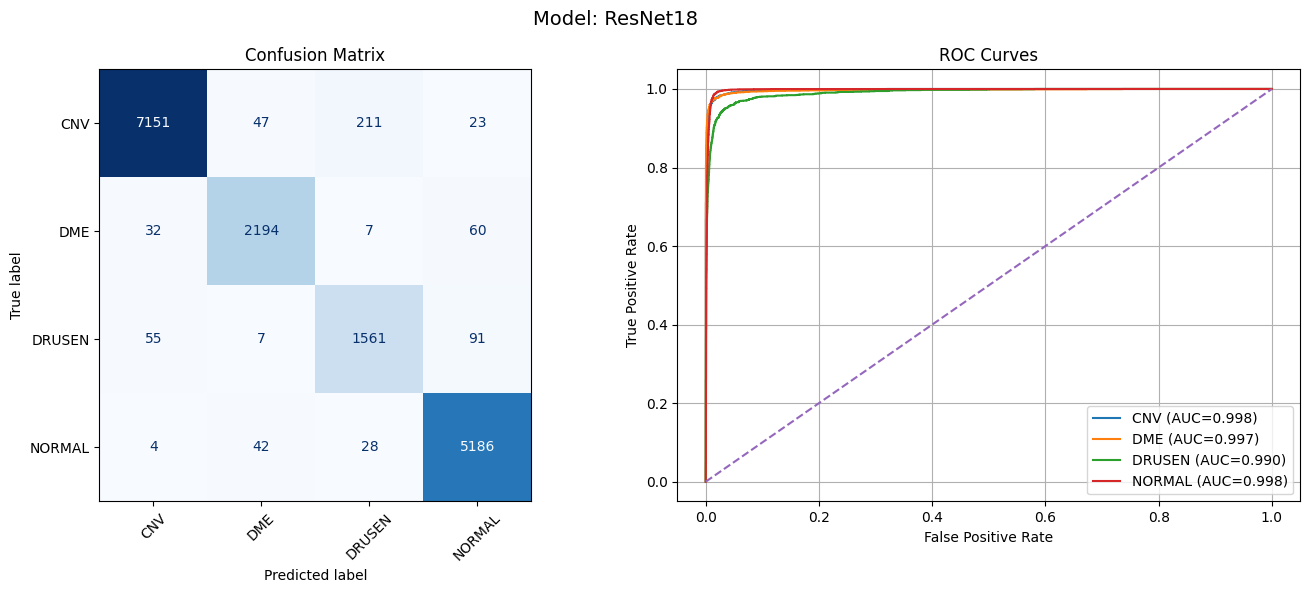

Raw predictions saved for comparison at: /content/drive/MyDrive/plots/resnet_aug/ResNet18_results.pth


In [ ]:
# Test ResNet18 with Augmentation
results_dict = {}

print("\n" + "="*130)
print(f"{' '*40}Testing Final Model: ResNet18 with Augmentation")
print("="*130)

model = utils.build_model(model_name='resnet18').to(device)
model.load_state_dict(torch.load(f"{path_final_models}/resnet_augmented_final.pth", map_location=device))

gold, preds, probs = utils.test_model(
    model=model,
    test_dataloader=test_loader,
    device=device,
    class_names=["CNV","DME","DRUSEN","NORMAL"],
    results_dict=results_dict,
    model_name='ResNet18',
    augmented=True,
    path_plots=path_plots
)

In [13]:
results_resnet_aug = torch.load(f"{path_plots}/ResNet18_results.pth", weights_only=False)

In [14]:
print(classification_report(results_resnet_aug['gold_labels'], results_resnet_aug['predictions'],
                            target_names=["CNV","DME","DRUSEN","NORMAL"], digits=4))

              precision    recall  f1-score   support

         CNV     0.9874    0.9622    0.9746      7432
         DME     0.9581    0.9568    0.9575      2293
      DRUSEN     0.8639    0.9107    0.8867      1714
      NORMAL     0.9675    0.9859    0.9766      5260

    accuracy                         0.9637     16699
   macro avg     0.9442    0.9539    0.9489     16699
weighted avg     0.9645    0.9637    0.9639     16699



In [19]:
ece = MulticlassCalibrationError(num_classes=4, n_bins=10)
ece_score = ece(torch.tensor(results_resnet_aug['probabilities']), torch.tensor(results_resnet_aug['gold_labels']))
print(f"ECE: {ece_score.item():.4f}")

ECE: 0.0080


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running in Colab environment.
The path are:
Final Models: /content/drive/MyDrive/Final_Models/resnet_no_aug
Hackathon Checkpoints: /content/drive/MyDrive/hackathon_checkpoints/resnet_no_aug
Plots: /content/drive/MyDrive/plots/resnet_no_aug
OCT Models: /content/drive/MyDrive/oct_models/resnet_no_aug

                                        Testing Final Model: ResNet18 without Augmentation


Testing: 100%|██████████| 33/33 [03:30<00:00,  6.39s/batch]



--- Metrics ---
Accuracy: 0.9348 | Precision: 0.9016 | Recall: 0.9194 | F1 Score: 0.9099
Plot saved to /content/drive/MyDrive/plots/resnet_no_aug/resnet18_cm_roc_not_aug.png


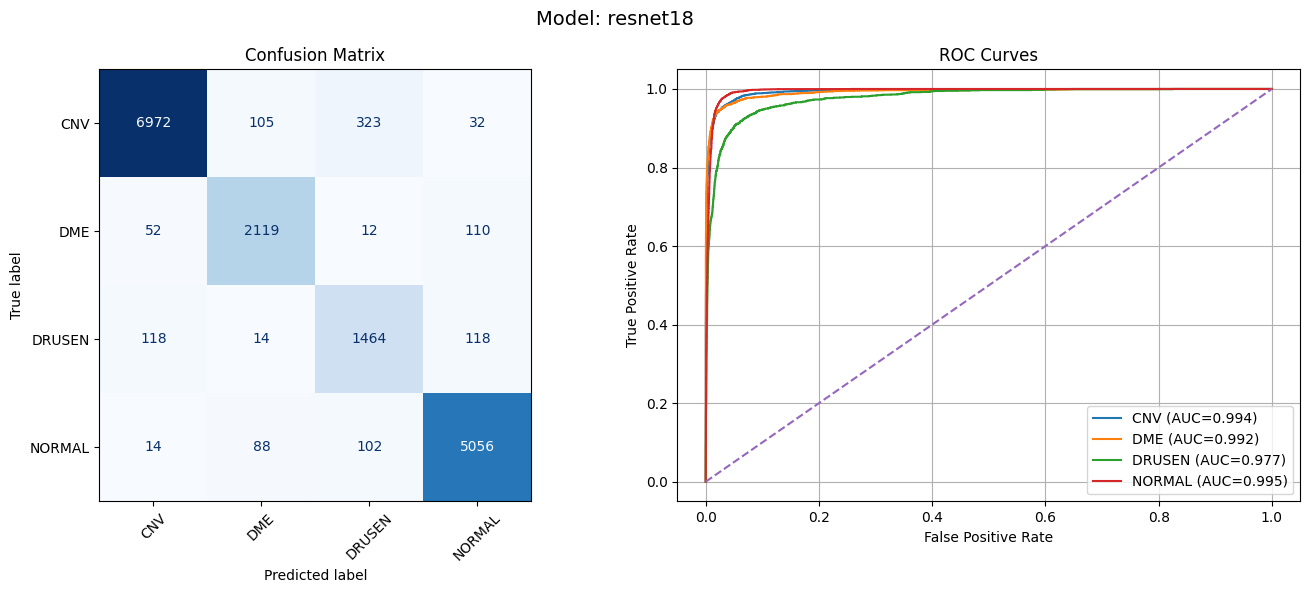

Raw predictions saved for comparison at: /content/drive/MyDrive/plots/resnet_no_aug/resnet18_results.pth


In [13]:
# Test ResNet18 without Augmentation
results_dict = {}
path_final_models, _, path_plots, path_oct_models = utils.create_paths(model_name=model_name, augmented=False, env=env)

print("\n" + "="*130)
print(f"{' '*40}Testing Final Model: ResNet18 without Augmentation")
print("="*130)

model = utils.build_model(model_name='resnet18').to(device)

model.load_state_dict(torch.load(f"{path_final_models}/resnet_base_final.pth", map_location=device))

gold, preds, probs = utils.test_model(
    model=model,
    test_dataloader=test_loader,
    device=device,
    class_names=["CNV","DME","DRUSEN","NORMAL"],
    results_dict=results_dict,
    model_name='resnet18',
    augmented=False,
    path_plots=path_plots
)

In [32]:
# Create new paths for ResNet18 Base
path_final_models, _, path_plots, path_oct_models = utils.create_paths(model_name=model_name, augmented=False, env=env)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running in Colab environment.
The path are:
Final Models: /content/drive/MyDrive/Final_Models/resnet_no_aug
Hackathon Checkpoints: /content/drive/MyDrive/hackathon_checkpoints/resnet_no_aug
Plots: /content/drive/MyDrive/plots/resnet_no_aug
OCT Models: /content/drive/MyDrive/oct_models/resnet_no_aug


In [16]:
# Load results from ResNet18 Base
results_resnet_base = torch.load(f"{path_plots}/resnet18_results.pth", weights_only=False)

In [17]:
print(classification_report(results_resnet_base['gold_labels'], results_resnet_base['predictions'],
                            target_names=["CNV","DME","DRUSEN","NORMAL"], digits=4))

              precision    recall  f1-score   support

         CNV     0.9743    0.9381    0.9559      7432
         DME     0.9110    0.9241    0.9175      2293
      DRUSEN     0.7701    0.8541    0.8100      1714
      NORMAL     0.9511    0.9612    0.9561      5260

    accuracy                         0.9348     16699
   macro avg     0.9016    0.9194    0.9099     16699
weighted avg     0.9373    0.9348    0.9357     16699



In [18]:
ece = MulticlassCalibrationError(num_classes=4, n_bins=10)
ece_score = ece(torch.tensor(results_resnet_base['probabilities']), torch.tensor(results_resnet_base['gold_labels']))
print(f"ECE: {ece_score.item():.4f}")

ECE: 0.0085


In [38]:
# Create paths for DenseNet121 Base
model_name = "densenet"

path_final_models, _, path_plots, path_oct_models = utils.create_paths(model_name=model_name, augmented=False, env=env)

####################################################################################
Hello!!! Thank you for using OCT Classification.
Please tell me if you are running code on Kaggle, colab or Local? (kaggle/colab/local): colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running in Colab environment.
The path are:
Final Models: /content/drive/MyDrive/Final_Models/densenet_no_aug
Hackathon Checkpoints: /content/drive/MyDrive/hackathon_checkpoints/densenet_no_aug
Plots: /content/drive/MyDrive/plots/densenet_no_aug
OCT Models: /content/drive/MyDrive/oct_models/densenet_no_aug



                                        Testing Final Model: DenseNet121 without Augmentation


Testing: 100%|██████████| 261/261 [1:17:15<00:00, 17.76s/batch]



--- Metrics ---
Accuracy: 0.9372 | Precision: 0.9097 | Recall: 0.9123 | F1 Score: 0.9110
Plot saved to /content/drive/MyDrive/plots/densenet_no_aug/DenseNet121_cm_roc_not_aug.png


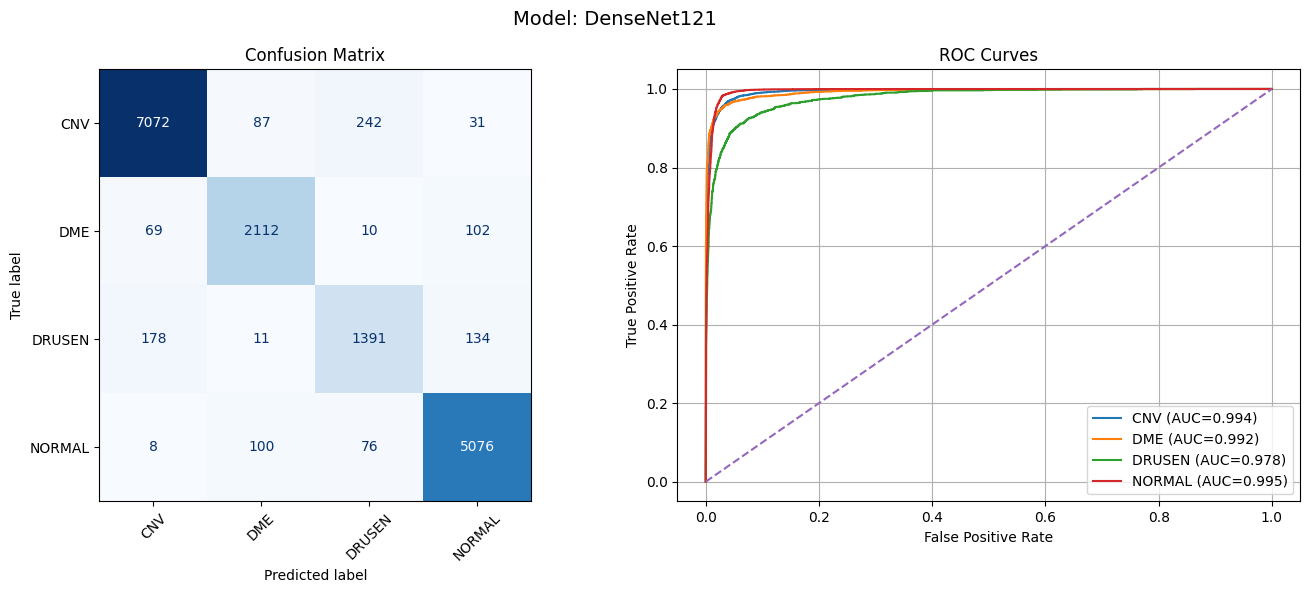

Raw predictions saved for comparison at: /content/drive/MyDrive/plots/densenet_no_aug/DenseNet121_results.pth


In [ ]:
# Test DenseNet121 without Augmentation
results_dict = {}

print("\n" + "="*130)
print(f"{' '*40}Testing Final Model: DenseNet121 without Augmentation")
print("="*130)

model = utils.build_model(model_name='densenet121').to(device)

model.load_state_dict(torch.load(f"{path_final_models}/densenet_base_final.pth", map_location=device))

gold, preds, probs = utils.test_model(
    model=model,
    test_dataloader=test_loader,
    device=device,
    class_names=["CNV","DME","DRUSEN","NORMAL"],
    results_dict=results_dict,
    model_name='DenseNet121',
    augmented=False,
    path_plots=path_plots
)

In [39]:
# Load results from DenseNet121 Base
results_densenet_base = torch.load(f"{path_plots}/DenseNet121_results.pth", weights_only=False)

In [42]:
print(classification_report(results_densenet_base['gold_labels'], results_densenet_base['predictions'],
                            target_names=["CNV","DME","DRUSEN","NORMAL"], digits=4))

              precision    recall  f1-score   support

         CNV     0.9652    0.9516    0.9583      7432
         DME     0.9143    0.9211    0.9177      2293
      DRUSEN     0.8092    0.8116    0.8104      1714
      NORMAL     0.9500    0.9650    0.9575      5260

    accuracy                         0.9372     16699
   macro avg     0.9097    0.9123    0.9110     16699
weighted avg     0.9374    0.9372    0.9373     16699



In [41]:
ece = MulticlassCalibrationError(num_classes=4, n_bins=10)
ece_score = ece(torch.tensor(results_densenet_base['probabilities']), torch.tensor(results_densenet_base['gold_labels']))
print(f"ECE: {ece_score.item():.4f}")

ECE: 0.0117


In [4]:
# Create paths for DenseNet121 Augmented
model_name = "densenet"

path_final_models, _, path_plots, path_oct_models = utils.create_paths(model_name=model_name, augmented=True, env='colab')

Mounted at /content/drive
Running in Colab environment.
The path are:
Final Models: /content/drive/MyDrive/Final_Models/densenet_aug
Hackathon Checkpoints: /content/drive/MyDrive/hackathon_checkpoints/densenet_aug
Plots: /content/drive/MyDrive/plots/densenet_aug
OCT Models: /content/drive/MyDrive/oct_models/densenet_aug



                                        Testing Final Model: DenseNet121 with Augmentation


Testing: 100%|██████████| 33/33 [04:43<00:00,  8.59s/batch]



--- Metrics ---
Accuracy: 0.9666 | Precision: 0.9480 | Recall: 0.9586 | F1 Score: 0.9531
Plot saved to /content/drive/MyDrive/plots/densenet_aug/DenseNet121_cm_roc_not_aug.png


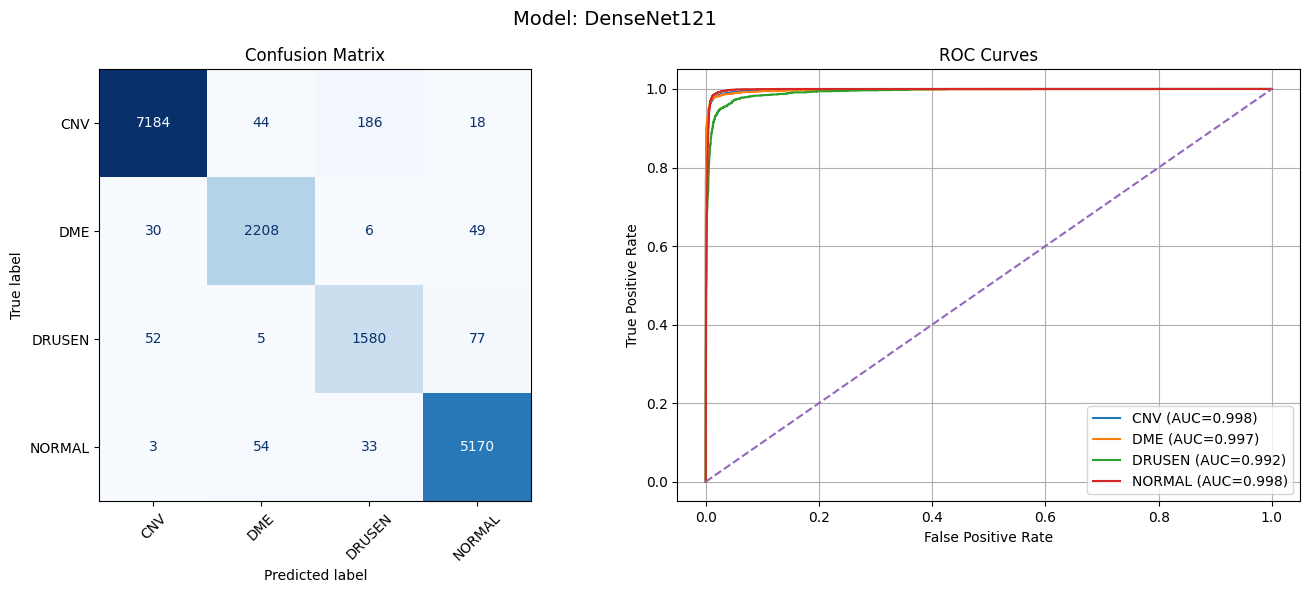

Raw predictions saved for comparison at: /content/drive/MyDrive/plots/densenet_aug/DenseNet121_results.pth


In [13]:
# Test DenseNet121 with Augmentation
results_dict = {}

print("\n" + "="*130)
print(f"{' '*40}Testing Final Model: DenseNet121 with Augmentation")
print("="*130)

model = utils.build_model(model_name='densenet121').to(device)

model.load_state_dict(torch.load(f"{path_final_models}/densenet_augmented_final.pth", map_location=device))

gold, preds, probs = utils.test_model(
    model=model,
    test_dataloader=test_loader,
    device=device,
    class_names=["CNV","DME","DRUSEN","NORMAL"],
    results_dict=results_dict,
    model_name='DenseNet121',
    augmented=True,
    path_plots=path_plots
)

In [10]:
# Load results from DenseNet121 Augmented
results_densenet_aug = torch.load(f"{path_plots}/DenseNet121_results.pth", weights_only=False)
gold_labels, preds, probs =  results_densenet_aug['gold_labels'], results_densenet_aug['predictions'], results_densenet_aug['probabilities']

In [15]:
print(classification_report(results_densenet_aug['gold_labels'], results_densenet_aug['predictions'],
                            target_names=["CNV","DME","DRUSEN","NORMAL"], digits=4))

              precision    recall  f1-score   support

         CNV     0.9883    0.9666    0.9773      7432
         DME     0.9554    0.9629    0.9592      2293
      DRUSEN     0.8753    0.9218    0.8980      1714
      NORMAL     0.9729    0.9829    0.9779      5260

    accuracy                         0.9666     16699
   macro avg     0.9480    0.9586    0.9531     16699
weighted avg     0.9673    0.9666    0.9669     16699



In [16]:
ece = MulticlassCalibrationError(num_classes=4, n_bins=10)
ece_score = ece(torch.tensor(results_densenet_aug['probabilities']), torch.tensor(results_densenet_aug['gold_labels']))
print(f"ECE: {ece_score.item():.4f}")

ECE: 0.0081


OVERALL STATS:
High-confidence wrong: 222/16699


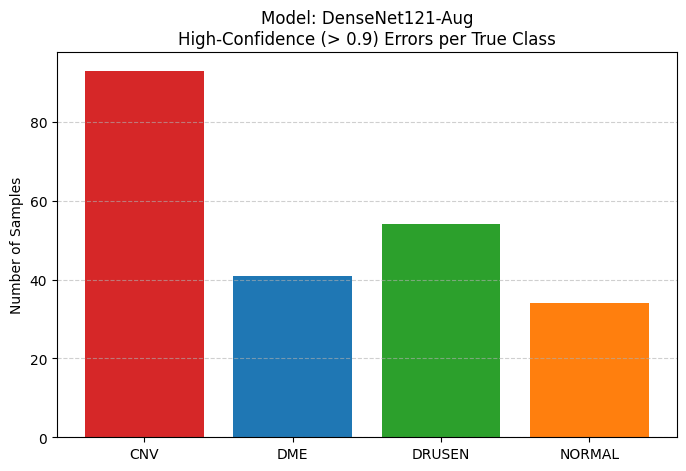

In [17]:
# Error Analysis for DenseNet121 - Augmented

class_names = ["CNV", "DME", "DRUSEN", "NORMAL"]
class_colors = ["#d62728", "#1f77b4", "#2ca02c", "#ff7f0e"]
threshold = 0.9

# Confidence and Error Masks
pred_conf = probs[np.arange(len(preds)), preds]
correct = (preds == gold_labels)
high_conf_wrong_mask = (~correct) & (pred_conf > threshold)

print(f"OVERALL STATS:")
print(f"High-confidence wrong: {np.sum(high_conf_wrong_mask)}/{len(preds)}")

# High-Confidence Errors per True Class
misclassified_counts = [np.sum((gold_labels == i) & high_conf_wrong_mask) for i in range(4)]

plt.figure(figsize=(8, 5))
plt.bar(class_names, misclassified_counts, color=class_colors)
plt.title(f"Model: DenseNet121-Aug\nHigh-Confidence (> {threshold}) Errors per True Class", fontsize=12)
plt.ylabel("Number of Samples")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig(f"{path_plots}/high_conf_errors_per_true_class.png", dpi=300)
plt.show()

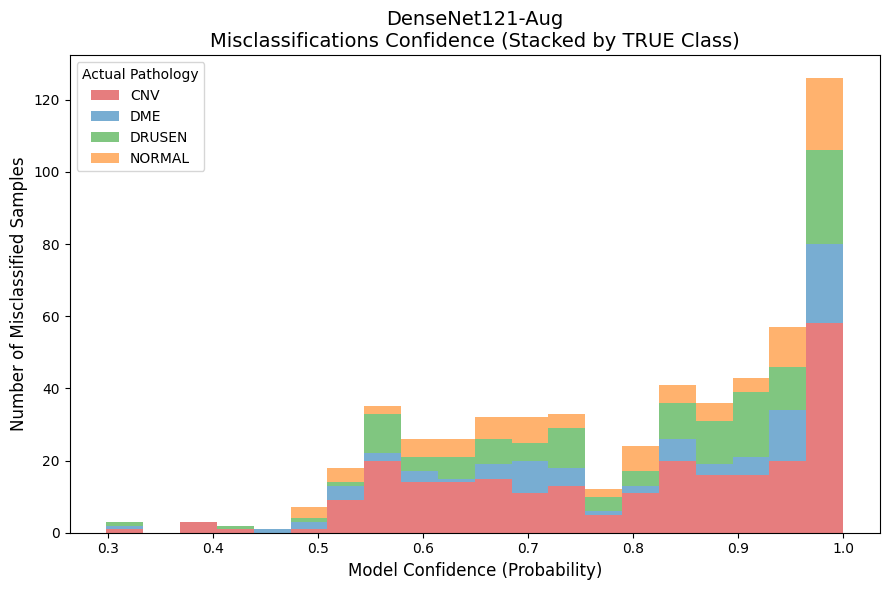

In [18]:
# Stacked Histogram: Confidence grouped by TRUE CLASS
# This shows exactly which actual diseases the model is missing confidently
incorrect_conf_by_true_class = [
    pred_conf[(gold_labels == i) & (~correct)]
    for i in range(len(class_names))
]

plt.figure(figsize=(9, 6))
plt.hist(
    incorrect_conf_by_true_class,
    bins=20,
    stacked=True,
    color=class_colors,
    label=class_names,
    alpha=0.6
)
plt.xlabel("Model Confidence (Probability)", fontsize=12)
plt.ylabel("Number of Misclassified Samples", fontsize=12)
plt.title("DenseNet121-Aug\nMisclassifications Confidence (Stacked by TRUE Class)", fontsize=14)
plt.legend(title="Actual Pathology")
plt.tight_layout()
plt.savefig(f"{path_plots}/confidence_stacked_true_class.png", dpi=300)
plt.show()

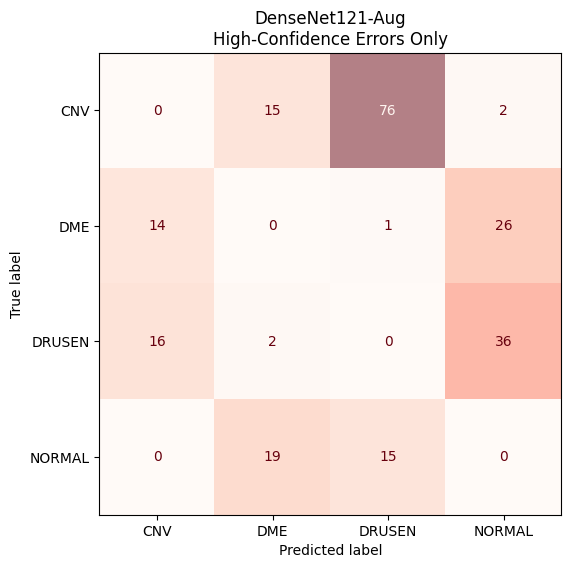

In [19]:
if np.sum(high_conf_wrong_mask) > 0:
    hc_cm = confusion_matrix(gold_labels[high_conf_wrong_mask], preds[high_conf_wrong_mask], labels=range(4))

    fig, ax = plt.subplots(figsize=(6, 6))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    disp = ConfusionMatrixDisplay(confusion_matrix=hc_cm, display_labels=class_names)
    disp.plot(cmap="Reds", ax=ax, colorbar=False)
    disp.im_.set_alpha(0.5)
    ax.set_title(f"DenseNet121-Aug\nHigh-Confidence Errors Only")

    # 3. Save with explicit non-transparency
    plt.savefig(
        f"{path_plots}/high_conf_errors_only_cm.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()